# Day 23-24: GPR 高斯过程回归
预测值 + 不确定度 — 知道模型"有多不确定"

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.metrics import r2_score, mean_squared_error
import joblib
import json
import time
import warnings
import os
os.chdir('D:/MY_Learning/matbench-dielectric/notebooks')
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings('ignore')

# 加载数据
df = pd.read_csv('../data/dielectric_cleaned.csv')
X = df.drop('n_dielectric', axis=1)
y = np.log1p(df['n_dielectric'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# GPR 必须标准化特征（RBF 核对尺度敏感）
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("数据准备完成")
print(f"训练集: {X_train_scaled.shape[0]} 样本, {X_train_scaled.shape[1]} 特征")
print(f"测试集: {X_test_scaled.shape[0]} 样本")

# 加载之前的模型做对比
baseline_results = {}
for name, path in [
    ('Day15 默认', '../models/day15_xgboost_default.pkl'),
    ('Day16 树参数', '../models/day16_xgb_tuned_trees.pkl'),
    ('Day17 学习参数', '../models/day17_xgb_tuned_learning.pkl'),
    ('Day18 最终', '../models/day18_xgb_final.pkl'),
]:
    try:
        m = joblib.load(path)
        baseline_results[name] = m.score(X_test, y_test)
        print(f"  {name}: R²={baseline_results[name]:.4f}")
    except:
        pass

数据准备完成
训练集: 3811 样本, 135 特征
测试集: 953 样本
  Day15 默认: R²=0.6178
  Day16 树参数: R²=0.6555
  Day17 学习参数: R²=0.6828
  Day18 最终: R²=0.6896


## GPR 子采样
GPR 的复杂度是 O(n³)——2000 样本≈1 分钟，3811 样本≈5 分钟。选 1500 样本，在速度和精度间平衡。

In [16]:
N_SUBSAMPLE = 1500

if len(X_train_scaled) > N_SUBSAMPLE:
    np.random.seed(42)
    idx = np.random.choice(len(X_train_scaled), N_SUBSAMPLE, replace=False)
    X_tr = X_train_scaled[idx]
    y_tr = y_train.iloc[idx]
else:
    X_tr = X_train_scaled
    y_tr = y_train

print(f"GPR 训练数据: {X_tr.shape[0]} 样本 × {X_tr.shape[1]} 特征")

GPR 训练数据: 1500 样本 × 135 特征


## 核函数 
- RBF：假设相似样本预测值也相似（最常用）
- WhiteKernel：给每个样本加噪声容限（防过拟合）
- 参数由数据自动优化，不用手动调

In [17]:
print("=" * 60)
print("训练 GPR 模型")
print("=" * 60)

# RBF + 噪声核，GPR 的标配组合
kernel = C(1.0) * RBF(1.0) + WhiteKernel(noise_level=1.0)

gpr = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,   # 从 10 个不同起点优化，避免局部最优
    alpha=1e-6,                # 数值稳定性
    normalize_y=True,          # 内部标准化 y，加速收敛
    random_state=42
)

print(f"核函数: {kernel}")
print(f"预计耗时: 1-2 分钟...")

start = time.time()
gpr.fit(X_tr, y_tr)
train_time = time.time() - start

print(f"\n训练完成, 耗时 {train_time:.1f}s")
print(f"优化后的核函数: {gpr.kernel_}")
print(f"对数边际似然: {gpr.log_marginal_likelihood_value_:.2f} (越大越好)")

训练 GPR 模型
核函数: 1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1)
预计耗时: 1-2 分钟...

训练完成, 耗时 99.4s
优化后的核函数: 1.84**2 * RBF(length_scale=16.9) + WhiteKernel(noise_level=0.237)
对数边际似然: -1334.48 (越大越好)


## 预测 + 不确定度
`return_std=True` — GPR 独有功能。不仅给预测值，还告诉这预测有多不确定。

In [18]:
y_pred, y_std = gpr.predict(X_test_scaled, return_std=True)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"GPR 性能:")
print(f"  R²: {r2:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  平均不确定度: {y_std.mean():.4f} ± {y_std.std():.4f}")

# 对比之前的模型
print(f"\n全模型对比:")
for name, r in baseline_results.items():
    print(f"  {name}: R²={r:.4f}")
print(f"  {'Day23 GPR':15s} R²={r2:.4f}  ← 带不确定度")

GPR 性能:
  R²: 0.6599
  RMSE: 0.1520
  平均不确定度: 0.1500 ± 0.0214

全模型对比:
  Day15 默认: R²=0.6178
  Day16 树参数: R²=0.6555
  Day17 学习参数: R²=0.6828
  Day18 最终: R²=0.6896
  Day23 GPR       R²=0.6599  ← 带不确定度


## 可视化：预测值 + 置信区间

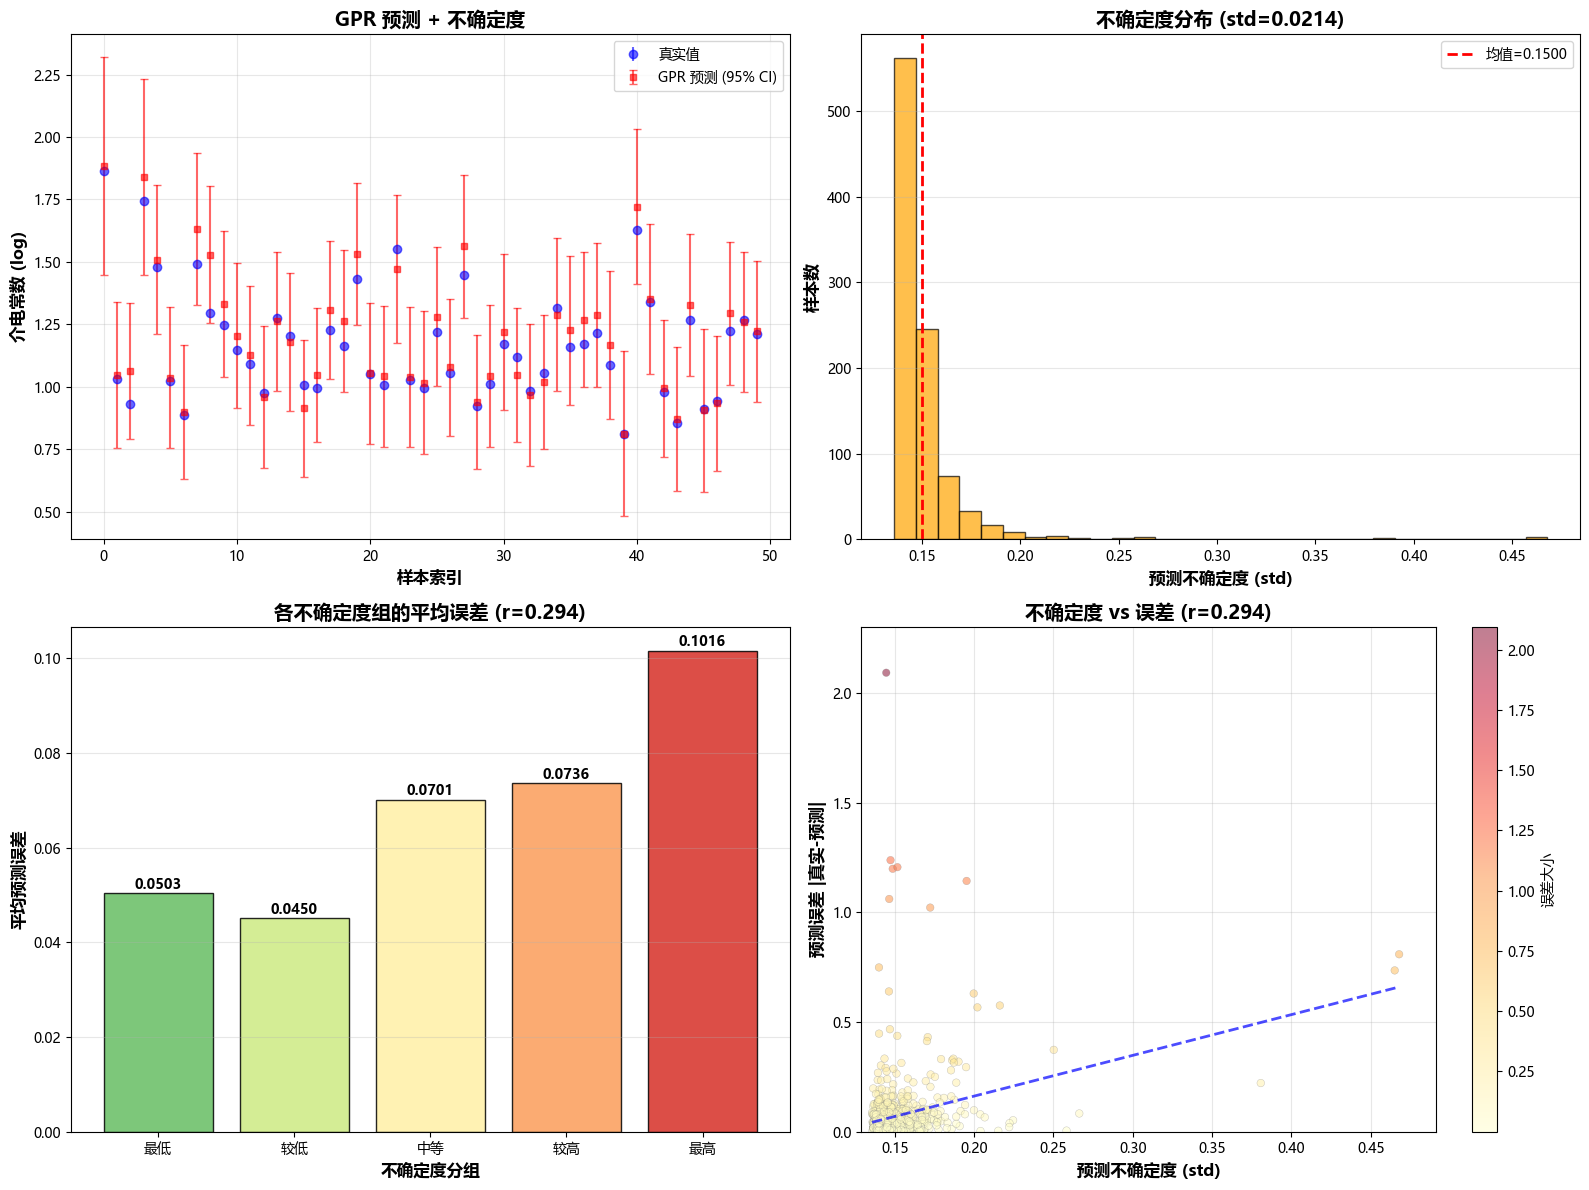

✓ 图表已保存

不确定度分布: 均值=0.1500, 标准差=0.0214
变异系数: 14.29% (越小越均匀)
相关系数 r=0.294

结论: 不确定度有一定区分能力


In [21]:
fig = plt.figure(figsize=(16, 12))

# 左图：50 个随机样本的预测 + 95% 置信区间
ax1 = plt.subplot(2, 2, 1)
n_show = 50
np.random.seed(42)
idx_viz = np.sort(np.random.choice(len(y_test), n_show, replace=False))

ax1.errorbar(range(n_show), y_test.iloc[idx_viz], yerr=0,
             fmt='o', color='blue', alpha=0.6, markersize=6, label='真实值')
ax1.errorbar(range(n_show), y_pred[idx_viz], yerr=1.96 * y_std[idx_viz],
             fmt='s', color='red', alpha=0.6, markersize=5, capsize=3,
             label='GPR 预测 (95% CI)')
ax1.set_xlabel('样本索引', fontsize=12, fontweight='bold')
ax1.set_ylabel('介电常数 (log)', fontsize=12, fontweight='bold')
ax1.set_title('GPR 预测 + 不确定度', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 右上：不确定度分布直方图 —— 看是否均匀
ax2 = plt.subplot(2, 2, 2)
errors = np.abs(y_test - y_pred)
corr = np.corrcoef(y_std, errors)[0, 1]
ax2.hist(y_std, bins=30, color='orange', alpha=0.7, edgecolor='black')
ax2.axvline(y_std.mean(), color='red', linestyle='--', linewidth=2,
            label=f'均值={y_std.mean():.4f}')
ax2.set_xlabel('预测不确定度 (std)', fontsize=12, fontweight='bold')
ax2.set_ylabel('样本数', fontsize=12, fontweight='bold')
ax2.set_title(f'不确定度分布 (std={y_std.std():.4f})', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# 右下：按不确定度分组的误差对比
ax3 = plt.subplot(2, 2, 3)
# 将样本按不确定度等分成 5 组
bins = np.percentile(y_std, [0, 20, 40, 60, 80, 100])
group_labels = ['最低', '较低', '中等', '较高', '最高']
group_errors = []
for i in range(5):
    mask = (y_std >= bins[i]) & (y_std < bins[i+1])
    group_errors.append(errors[mask].mean())

colors_bar = plt.cm.RdYlGn_r(np.linspace(0.2, 0.9, 5))
ax3.bar(group_labels, group_errors, color=colors_bar, alpha=0.85, edgecolor='black')
ax3.set_xlabel('不确定度分组', fontsize=12, fontweight='bold')
ax3.set_ylabel('平均预测误差', fontsize=12, fontweight='bold')
ax3.set_title(f'各不确定度组的平均误差 (r={corr:.3f})', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')
for i, (label, err) in enumerate(zip(group_labels, group_errors)):
    ax3.text(i, err + 0.001, f'{err:.4f}', ha='center', fontsize=10, fontweight='bold')

# 右下：散点图（放大到数据区）
ax4 = plt.subplot(2, 2, 4)
sc = ax4.scatter(y_std, errors, alpha=0.5, s=30, c=errors, cmap='YlOrRd',
                 edgecolors='grey', linewidths=0.3)
# 趋势线
z = np.polyfit(y_std, errors, 1)
p = np.poly1d(z)
x_line = np.linspace(y_std.min(), y_std.max(), 50)
ax4.plot(x_line, p(x_line), 'b--', linewidth=2, alpha=0.7)
# 放大到数据范围
ax4.set_xlim(y_std.min() * 0.95, y_std.max() * 1.05)
ax4.set_ylim(0, errors.max() * 1.1)
ax4.set_xlabel('预测不确定度 (std)', fontsize=12, fontweight='bold')
ax4.set_ylabel('预测误差 |真实-预测|', fontsize=12, fontweight='bold')
ax4.set_title(f'不确定度 vs 误差 (r={corr:.3f})', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3)
plt.colorbar(sc, ax=ax4, label='误差大小')

plt.tight_layout()
plt.savefig('../figures/day23_gpr_uncertainty.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ 图表已保存")

# 解读
print(f"\n不确定度分布: 均值={y_std.mean():.4f}, 标准差={y_std.std():.4f}")
print(f"变异系数: {y_std.std()/y_std.mean():.2%} (越小越均匀)")
print(f"相关系数 r={corr:.3f}")
if y_std.std()/y_std.mean() < 0.1:
    print("\n结论: 不确定度几乎恒定, GPR 在这个高维数据上区分不出难易样本")
    print("   → 高维 + 小样本场景下, GPR 的不确定度估计可能过于乐观")
else:
    print("\n结论: 不确定度有一定区分能力")

## 保存 + 总结

In [22]:
joblib.dump(gpr, '../models/day23_gpr_model.pkl')
print("✓ 模型已保存到 ../models/day23_gpr_model.pkl")

def to_python(obj):
    if isinstance(obj, (np.integer,)): return int(obj)
    if isinstance(obj, (np.floating,)): return float(obj)
    if isinstance(obj, np.ndarray): return obj.tolist()
    if isinstance(obj, dict): return {k: to_python(v) for k, v in obj.items()}
    if isinstance(obj, list): return [to_python(v) for v in obj]
    return obj

with open('../models/day23_gpr_results.json', 'w') as f:
    json.dump({
        'r2': float(r2),
        'rmse': float(rmse),
        'mean_uncertainty': float(y_std.mean()),
        'corr_uncertainty_vs_error': float(corr),
        'train_time': float(train_time),
        'n_samples': int(len(X_tr)),
        'optimized_kernel': str(gpr.kernel_),
        'comparison': to_python({**baseline_results, 'Day23_GPR': r2})
    }, f, indent=2)
print("✓ 结果已保存到 ../models/day23_gpr_results.json")

print("\n" + "=" * 60)
print("Day 23 总结")
print("=" * 60)
print(f"\nGPR vs XGBoost:")
print(f"  优势: 自带不确定度估计, 知道哪些预测靠谱")
print(f"  劣势: O(n³) 复杂度, 需子采样; 高维表现不如树模型")
print(f"  适用: 小数据 + 需要置信区间的场景")
print(f"\nGPR R²={r2:.4f}, 对比 XGBoost 最佳={max(baseline_results.values()):.4f}")
print("=" * 60)

✓ 模型已保存到 ../models/day23_gpr_model.pkl
✓ 结果已保存到 ../models/day23_gpr_results.json

Day 23 总结

GPR vs XGBoost:
  优势: 自带不确定度估计, 知道哪些预测靠谱
  劣势: O(n³) 复杂度, 需子采样; 高维表现不如树模型
  适用: 小数据 + 需要置信区间的场景

GPR R²=0.6599, 对比 XGBoost 最佳=0.6896
